# Product & Category Trends EDA

**Data Mode Configuration**:
- Set `USE_SAMPLE = False` in cell 1 for full dataset analysis (production)
- Set `USE_SAMPLE = True` in cell 1 for quick sample testing (development)

In [1]:
import importlib
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# --- Configuration ---
# set USE_SAMPLE = True for quick testing, False for full dataset analysis
USE_SAMPLE = False
TOP_N = 10  # Top N departments/products to display

# Setup project path
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "src").exists() and (parent / "data").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Reload the loader module
import instacart_quality.data_access as data_access_module
importlib.reload(data_access_module)

# Load order_products with product dimensions (products + aisles + departments)
# The convenience function handles all merging automatically
df = data_access_module.load_order_products_with_product_dim(use_sample=USE_SAMPLE, project_root=PROJECT_ROOT)

print(f"Loaded {len(df):,} order lines")
print(f"Data mode: {'SAMPLE' if USE_SAMPLE else 'FULL DATASET'}")
df.head()

Loaded 32,434,489 order lines
Data mode: FULL DATASET


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry


## Suggested Questions
- Which departments dominate order volume?
- Which aisles have highest reorder tendency?
- Which products are consistently top demand?

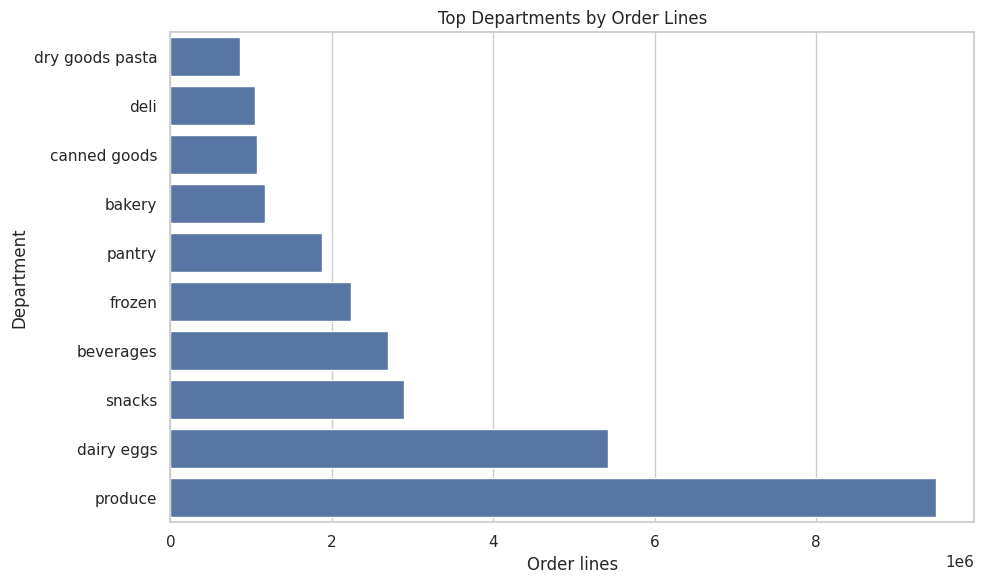

In [2]:
dept_counts = df["department"].value_counts().head(TOP_N).sort_values()
plt.figure(figsize=(10, 6))
sns.barplot(x=dept_counts.values, y=dept_counts.index, orient="h")
plt.title("Top Departments by Order Lines")
plt.xlabel("Order lines")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

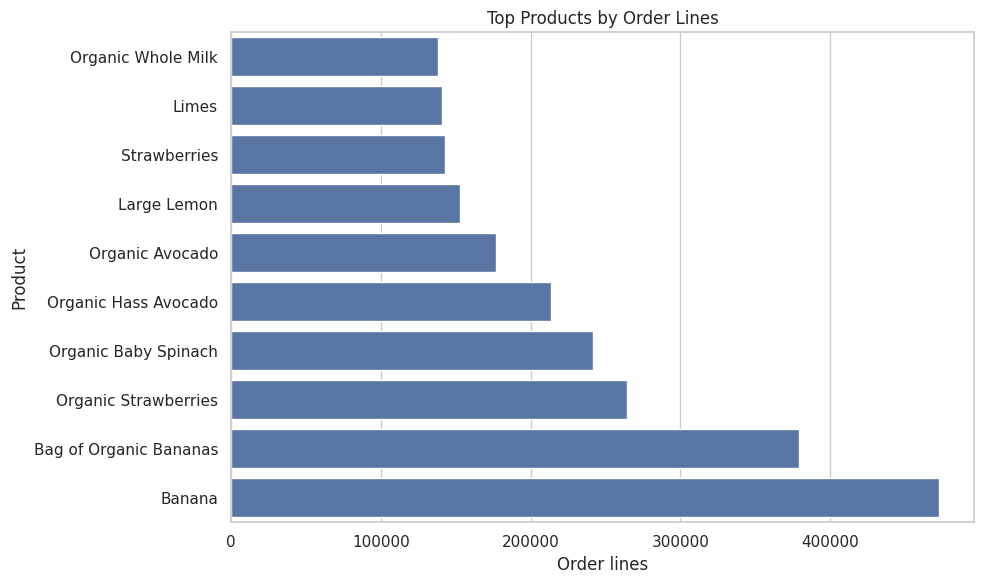

In [3]:
product_counts = df["product_name"].value_counts().head(TOP_N).sort_values()
plt.figure(figsize=(10, 6))
sns.barplot(x=product_counts.values, y=product_counts.index, orient="h")
plt.title("Top Products by Order Lines")
plt.xlabel("Order lines")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [4]:
import numpy as np

GLOBAL_REORDER_RATE = df["reordered"].mean()
PRIOR_STRENGTH = 40  # Bayesian smoothing strength; higher = more conservative
MIN_LINES_DEPT = 200 if USE_SAMPLE else 3000
MIN_LINES_PRODUCT = 60 if USE_SAMPLE else 1000

def build_reorder_profile(data: pd.DataFrame, group_col: str, min_lines: int, prior_strength: int):
    profile = (
        data.groupby(group_col, dropna=False)["reordered"]
        .agg(order_lines="size", reorders="sum")
        .reset_index()
    )
    profile["raw_reorder_rate"] = profile["reorders"] / profile["order_lines"]
    profile["smoothed_reorder_rate"] = (
        profile["reorders"] + prior_strength * GLOBAL_REORDER_RATE
    ) / (profile["order_lines"] + prior_strength)
    profile["lift_vs_global"] = profile["smoothed_reorder_rate"] / GLOBAL_REORDER_RATE

    # Wilson score interval for proportion uncertainty
    z = 1.96
    n = profile["order_lines"].astype(float)
    p = profile["raw_reorder_rate"].astype(float)
    denom = 1 + (z ** 2) / n
    center = p + (z ** 2) / (2 * n)
    margin = z * np.sqrt((p * (1 - p) / n) + ((z ** 2) / (4 * (n ** 2))))
    profile["ci_low"] = (center - margin) / denom
    profile["ci_high"] = (center + margin) / denom
    profile["ci_width"] = profile["ci_high"] - profile["ci_low"]

    filtered = (
        profile[profile["order_lines"] >= min_lines]
        .sort_values(["smoothed_reorder_rate", "order_lines"], ascending=[False, False])
        .reset_index(drop=True)
    )
    return filtered

dept_reorder_adv = build_reorder_profile(
    data=df, group_col="department", min_lines=MIN_LINES_DEPT, prior_strength=PRIOR_STRENGTH
)
product_reorder_adv = build_reorder_profile(
    data=df, group_col="product_name", min_lines=MIN_LINES_PRODUCT, prior_strength=PRIOR_STRENGTH
)

print(f"Global reorder rate: {GLOBAL_REORDER_RATE:.3f}")
display(
    dept_reorder_adv[[
        "department", "order_lines", "raw_reorder_rate",
        "smoothed_reorder_rate", "lift_vs_global", "ci_low", "ci_high"
    ]].head(10)
 )
display(
    product_reorder_adv[[
        "product_name", "order_lines", "raw_reorder_rate",
        "smoothed_reorder_rate", "lift_vs_global", "ci_low", "ci_high"
    ]].head(10)
)

Global reorder rate: 0.590


,department,order_lines,raw_reorder_rate,smoothed_reorder_rate,lift_vs_global,ci_low,ci_high
0,dairy eggs,5414016,0.669969,0.669968,1.136122,0.669572,0.670365
1,beverages,2690129,0.653460,0.653459,1.108126,0.652891,0.654029
2,produce,9479291,0.649913,0.649912,1.102111,0.649609,0.650216
3,bakery,1176787,0.628141,0.628140,1.065190,0.627267,0.629014
4,deli,1051249,0.607719,0.607718,1.030559,0.606785,0.608652
5,pets,97724,0.601285,0.601281,1.019642,0.598211,0.604351
6,babies,423802,0.578971,0.578972,0.981812,0.577484,0.580457
7,bulk,34573,0.577040,0.577055,0.978560,0.571824,0.582239
8,snacks,2887550,0.574180,0.574180,0.973686,0.573609,0.574750
9,alcohol,153696,0.569924,0.569929,0.966477,0.567447,0.572397


,product_name,order_lines,raw_reorder_rate,smoothed_reorder_rate,lift_vs_global,ci_low,ci_high
0,Whole Organic Omega 3 Milk,9108,0.860233,0.859050,1.456764,0.852960,0.867202
1,Half And Half Ultra Pasteurized,2921,0.861691,0.858017,1.455012,0.848696,0.873737
2,Organic Lactose Free Whole Milk,8477,0.859030,0.857765,1.454586,0.851460,0.866276
3,Organic Homogenized Whole Milk,3970,0.857683,0.855009,1.449912,0.846469,0.868205
4,"Milk, Organic, Vitamin D",20198,0.854342,0.853819,1.447893,0.849410,0.859140
5,Ultra-Purified Water,1489,0.857623,0.850613,1.442457,0.838952,0.874452
6,Organic Reduced Fat Milk,35663,0.850686,0.850393,1.442084,0.846949,0.854347
7,Goat Milk,5185,0.849952,0.847959,1.437957,0.839972,0.859413
8,Banana,472565,0.843501,0.843479,1.430360,0.842462,0.844534
9,Organic Whole Milk,9842,0.841191,0.840173,1.424752,0.833837,0.848279


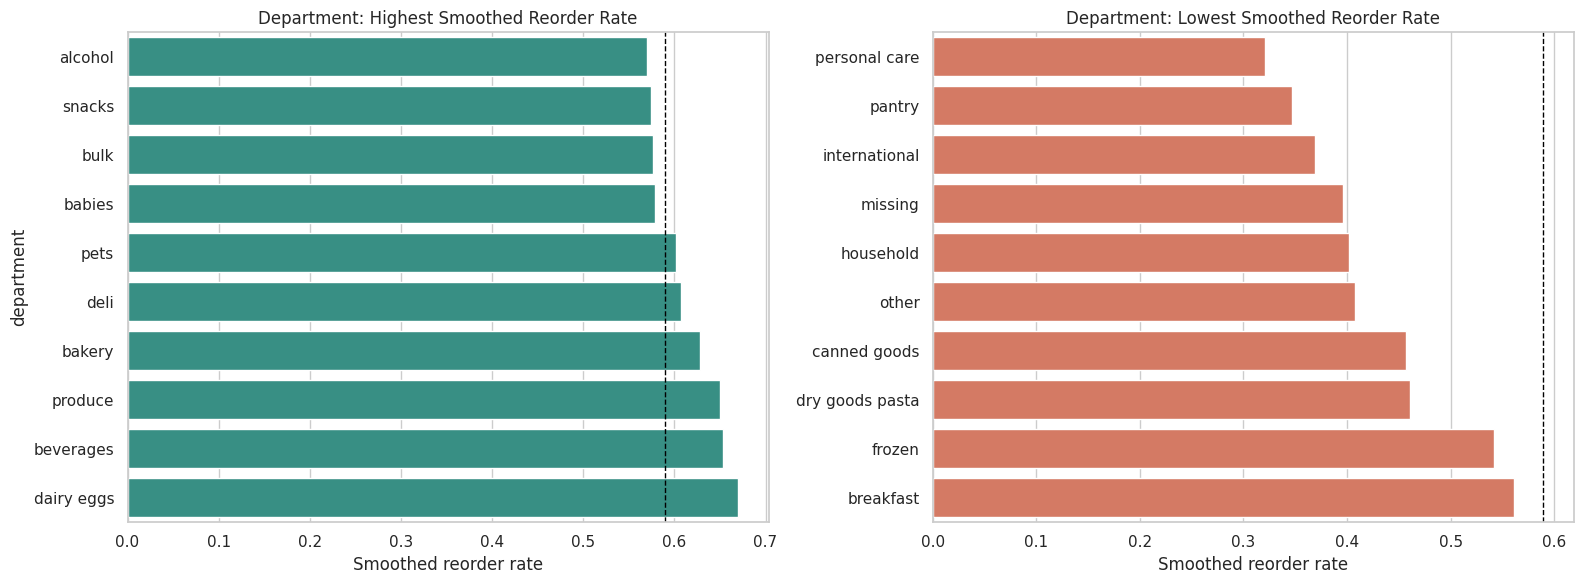

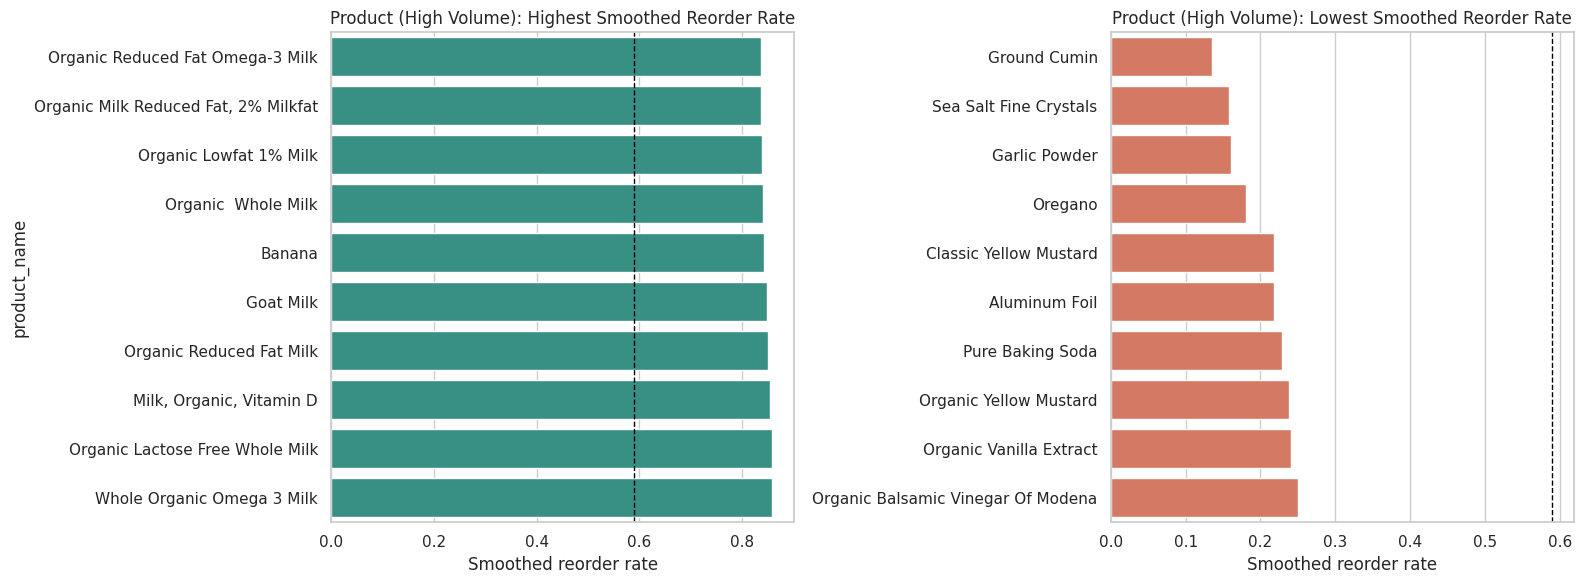

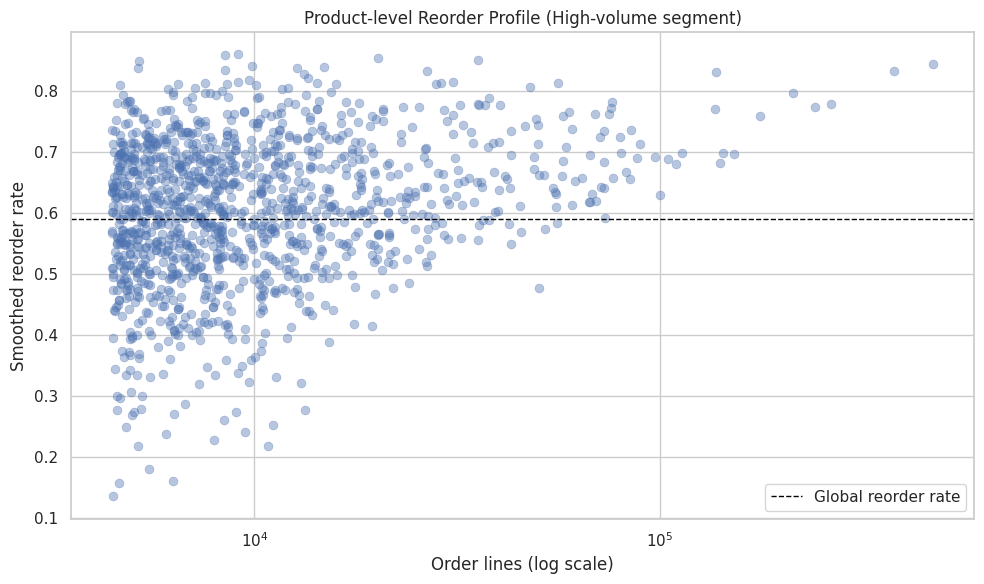

In [5]:
def plot_top_bottom(profile: pd.DataFrame, label_col: str, title_prefix: str, top_n: int = 12):
    top = profile.nlargest(top_n, "smoothed_reorder_rate").sort_values("smoothed_reorder_rate")
    bottom = profile.nsmallest(top_n, "smoothed_reorder_rate").sort_values("smoothed_reorder_rate")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)
    sns.barplot(data=top, x="smoothed_reorder_rate", y=label_col, ax=axes[0], color="#2a9d8f")
    axes[0].axvline(GLOBAL_REORDER_RATE, color="black", linestyle="--", linewidth=1)
    axes[0].set_title(f"{title_prefix}: Highest Smoothed Reorder Rate")
    axes[0].set_xlabel("Smoothed reorder rate")
    axes[0].set_ylabel(label_col)

    sns.barplot(data=bottom, x="smoothed_reorder_rate", y=label_col, ax=axes[1], color="#e76f51")
    axes[1].axvline(GLOBAL_REORDER_RATE, color="black", linestyle="--", linewidth=1)
    axes[1].set_title(f"{title_prefix}: Lowest Smoothed Reorder Rate")
    axes[1].set_xlabel("Smoothed reorder rate")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

# Department-level view (stable because of higher support)
plot_top_bottom(dept_reorder_adv, "department", "Department", top_n=min(TOP_N, len(dept_reorder_adv)))

# Product-level view: keep only high-volume segment using adaptive threshold
if len(product_reorder_adv) > 0:
    q_cut = product_reorder_adv["order_lines"].quantile(0.75)
    high_volume_products = product_reorder_adv[product_reorder_adv["order_lines"] >= q_cut].copy()

    # Ensure enough products for top/bottom comparison on small samples
    if len(high_volume_products) < min(2 * TOP_N, len(product_reorder_adv)):
        high_volume_products = product_reorder_adv.nlargest(
            min(max(2 * TOP_N, 20), len(product_reorder_adv)), "order_lines"
        ).copy()

    plot_top_bottom(
        high_volume_products,
        "product_name",
        "Product (High Volume)",
        top_n=min(TOP_N, len(high_volume_products))
    )

    # Relationship between volume and reorder tendency
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=high_volume_products.sample(min(1500, len(high_volume_products)), random_state=42),
        x="order_lines",
        y="smoothed_reorder_rate",
        alpha=0.4,
        s=40,
        edgecolor=None
    )
    plt.axhline(GLOBAL_REORDER_RATE, color="black", linestyle="--", linewidth=1, label="Global reorder rate")
    plt.xscale("log")
    plt.title("Product-level Reorder Profile (High-volume segment)")
    plt.xlabel("Order lines (log scale)")
    plt.ylabel("Smoothed reorder rate")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No product rows available after filtering.")

## Segmentation Analysis